In [167]:
# Importing dependencies
import sklearn
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
import torch.nn
import torch.optim

In [169]:
# Loading the data
data = pd.read_csv("DataCoSupplyChainDataset.csv", encoding='latin-1')

In [181]:
# EDA analysis
print(data.info())
missing = data.isnull().sum()
print(missing[missing > 0])

# data is actually reversed so it needs to be sorted based on time
data['order date (DateOrders)'] = pd.to_datetime(data['order date (DateOrders)'])
sorted_data = data.sort_values('order date (DateOrders)').set_index('order date (DateOrders)')
sorted_data = sorted_data.resample('D').sum()
sorted_data = sorted_data[:'2017-9-30'] # tail of target variable is near 0 at the end so trim


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   Type                           180519 non-null  object        
 1   Days for shipping (real)       180519 non-null  int64         
 2   Days for shipment (scheduled)  180519 non-null  int64         
 3   Benefit per order              180519 non-null  float64       
 4   Sales per customer             180519 non-null  float64       
 5   Delivery Status                180519 non-null  object        
 6   Late_delivery_risk             180519 non-null  int64         
 7   Category Id                    180519 non-null  int64         
 8   Category Name                  180519 non-null  object        
 9   Customer City                  180519 non-null  object        
 10  Customer Country               180519 non-null  object        
 11  

In [182]:
# Feature Selection
data = sorted_data.drop(['Customer Email', 'Customer Password', 'Customer Fname', 'Customer Lname', 
                         'Customer Street', 'Product Image', 'Customer City','Type', 'Product Name', 
                         'Customer State','Order State', 'Order City', 'shipping date (DateOrders)', 
                         'Department Name', 'Delivery Status', 'Category Name', 'Customer Country', 
                         'Order Region', 'Order Status', 'Shipping Mode', 'Category Id', 'Customer Id',
                         'Department Id', 'Order Customer Id', 'Order Id', 'Order Item Cardprod Id', 
                         'Order Item Id', 'Product Card Id', 'Order Zipcode', 'Product Description', 
                         'Product Category Id', 'Customer Zipcode'], axis=1)

print(data.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1004 entries, 2015-01-01 to 2017-09-30
Freq: D
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Days for shipping (real)       1004 non-null   int64  
 1   Days for shipment (scheduled)  1004 non-null   int64  
 2   Benefit per order              1004 non-null   float64
 3   Sales per customer             1004 non-null   float64
 4   Late_delivery_risk             1004 non-null   int64  
 5   Customer Segment               1004 non-null   object 
 6   Latitude                       1004 non-null   float64
 7   Longitude                      1004 non-null   float64
 8   Market                         1004 non-null   object 
 9   Order Country                  1004 non-null   object 
 10  Order Item Discount            1004 non-null   float64
 11  Order Item Discount Rate       1004 non-null   float64
 12  Order Item Product Pri

In [183]:
# Further Preprocessing + train/test split

# Split target from data
y = data['Order Item Quantity']
X = data.drop('Order Item Quantity', axis=1)

# Encode object types using dummies -- No data leakage by doing it before splitting because no statistical method used.
X_encoded = pd.get_dummies(X, columns=['Customer Segment', 'Market', 'Order Country'], dtype='float')

# Divide into train / test split
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X_encoded, y, random_state=42, shuffle=False)

# easy way to access numerical cols only.
numerical_cols = [col for col in X_train.columns if col not in ['Customer Segment', 'Market', 'Order Country', 
                                                                 'Late_delivery_risk', 'Product Status']]

# Scaling numerical columns -- after splitting to prevent data leakage.
X_scaler = MinMaxScaler()
X_train[numerical_cols] = X_scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = X_scaler.transform(X_test[numerical_cols])

y_scaler = MinMaxScaler()
y_train = y_scaler.fit_transform(y_train.values.reshape(-1,1))
y_test = y_scaler.transform(y_test.values.reshape(-1,1))

In [185]:
# Preprocessing for LSTM
# Create helper function to sequence the data
def create_sequence(X, y, seq_len):
    X_seq, y_seq = [], []
    for i in range(X.shape[0] - seq_len):
        new_seq_X = X[i : i+seq_len]
        new_seq_y = y[i+seq_len]
        X_seq.append(new_seq_X)
        y_seq.append(new_seq_y)
    return np.array(X_seq), np.array(y_seq)
    
# Create sequences in data for time series forecasting
X_train_seq, y_train_seq = create_sequence(X_train, y_train, seq_len=7) # sequence length to 7 days
X_test_seq, y_test_seq = create_sequence(X_test, y_test, seq_len=7)

# Turn numpy arrays into torch tensors 
X_train_tensor = torch.FloatTensor(X_train_seq)
X_test_tensor = torch.FloatTensor(X_test_seq)
y_train_tensor = torch.FloatTensor(y_train_seq)
y_test_tensor = torch.FloatTensor(y_test_seq)

from torch.utils.data import TensorDataset, DataLoader
# Create TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset  = TensorDataset(X_test_tensor,  y_test_tensor)

train_loader  = DataLoader(train_dataset, batch_size=16, shuffle=False) 
test_loader   = DataLoader(test_dataset,  batch_size=16, shuffle=False)

In [187]:
# LSTM Model definition
class DemandModel(torch.nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size) -> None:
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = torch.nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size, 
            num_layers=num_layers, 
            batch_first=True,
            dropout=0)
        self.linear = torch.nn.Linear(hidden_size, output_size)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_step = lstm_out[:, -1, :]
        out = self.linear(last_step)
        return out

HIDDEN_SIZE = 32
NUM_LAYERS = 1
OUTPUT_SIZE = 1
model = DemandModel(X_train_tensor.shape[2], HIDDEN_SIZE, NUM_LAYERS, OUTPUT_SIZE)

In [188]:
# model training
learning_rate = 0.001
epochs = 300
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
loss_fn = torch.nn.MSELoss()
train_losses, val_losses = [], []

# Training loop
for epoch in range(epochs):
    # Set model to training mode
    model.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        # Clear previous gradients to prevent accumulation
        optimizer.zero_grad()
        # Forward pass
        preds = model(X_batch)
        # Calculate loss
        loss = loss_fn(preds, y_batch)
        #Backward pass
        loss.backward()
        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        # Update weights based on computed gradients
        optimizer.step()
        batch_losses.append(loss.item())
    # Store average training loss for this epoch
    train_losses.append(float(np.mean(batch_losses)))

    # Set model to evaluation mode
    model.eval()
    #Disable gradient calculation to save memory and computations during inference
    with torch.no_grad():
        val_batch_losses = []
        for X_batch, y_batch in test_loader:
            preds = model(X_batch)
            val_batch_losses.append(loss_fn(preds, y_batch).item())
        val_losses.append(float(np.mean(val_batch_losses)))

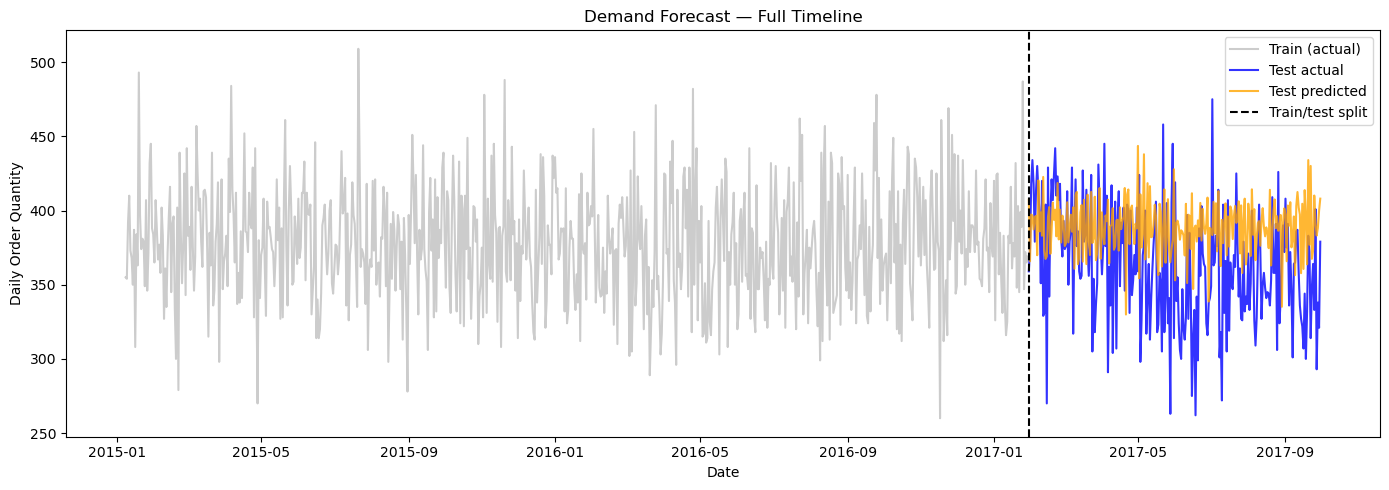

In [294]:
# Evaluation of model
model.eval()
with torch.no_grad():
    y_pred_scaled = model(X_test_tensor).numpy() 

# Inverse scale to get original vals
y_pred = y_scaler.inverse_transform(y_pred_scaled) 
y_true = y_scaler.inverse_transform(y_test_tensor.numpy())

# Full time-series plot of predicted vs actual values
train_dates = data.index[7 : 7 + len(y_train)]
test_dates  = data.index[len(X_train) + 7 : len(X_train) + 7 + len(y_pred)]

plt.figure(figsize=(14, 5))
plt.plot(train_dates, y_scaler.inverse_transform(y_train), 
         color='grey', alpha=0.4, label="Train (actual)")
plt.plot(test_dates, y_true,  label="Test actual",    color='blue', alpha=0.8)
plt.plot(test_dates, y_pred,  label="Test predicted", color='orange', alpha=0.8)
plt.axvline(x=test_dates[0], color='black', linestyle='--', label="Train/test split")
plt.xlabel("Date")
plt.ylabel("Daily Order Quantity")
plt.title("Demand Forecast — Full Timeline")
plt.legend()
plt.tight_layout()
plt.savefig('results.png',bbox_inches='tight', dpi=150)
plt.show()

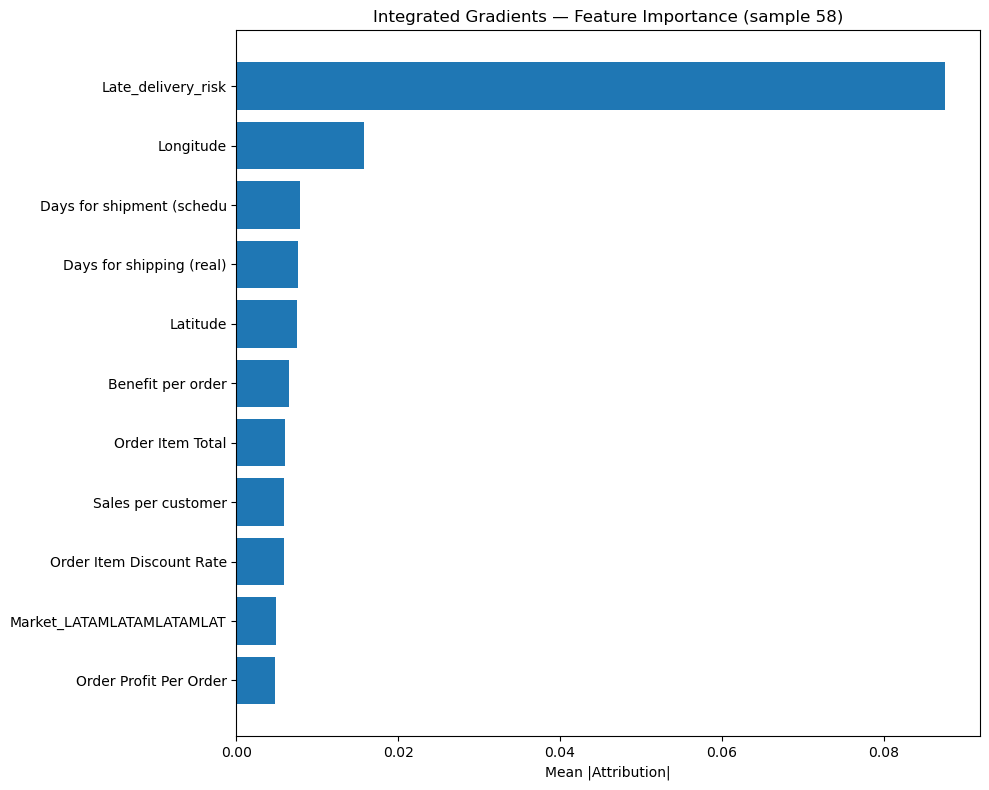

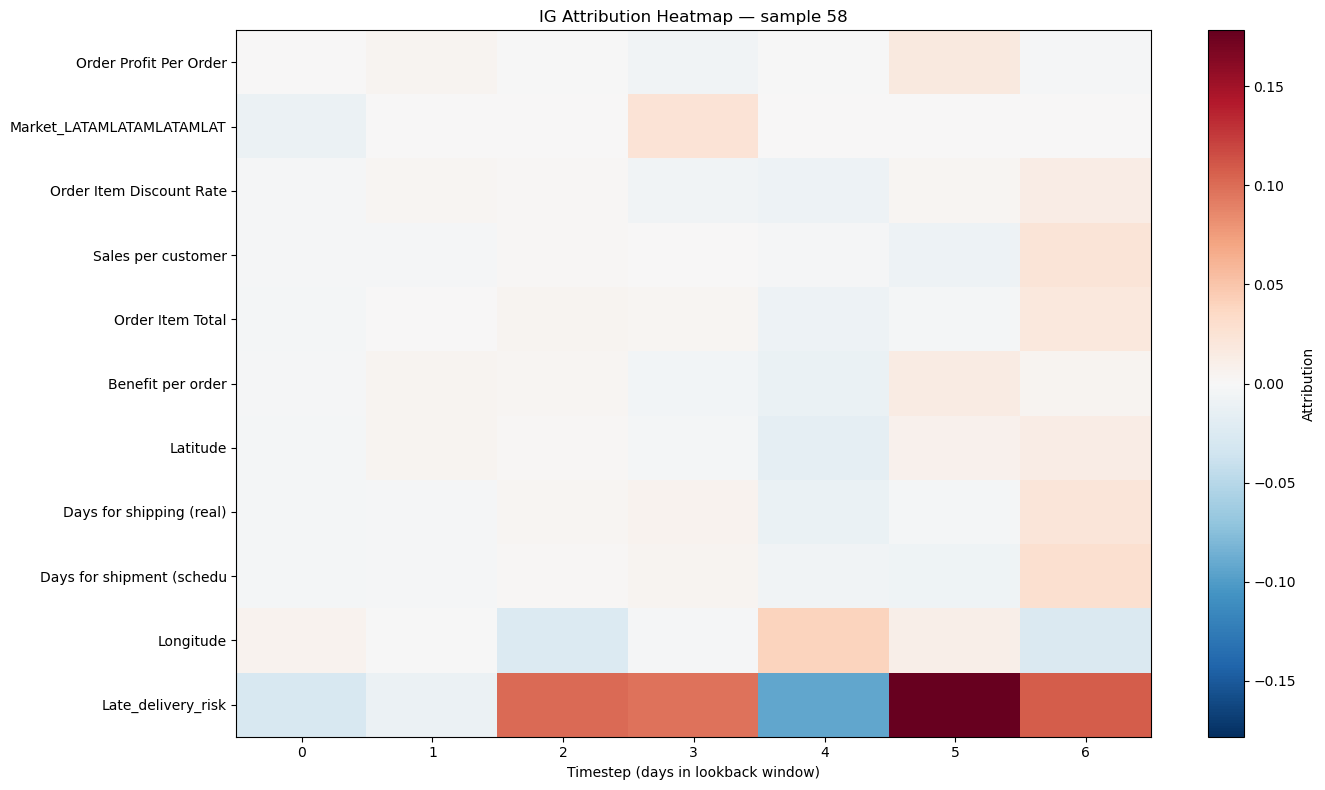

In [312]:
# Integrated Gradients
from captum.attr import IntegratedGradients
ig = IntegratedGradients(model)

# Run IG on a test sample
model.eval()
sample_id = 58
X_sample = X_test_tensor[sample_id].unsqueeze(0)  # (1, seq_len, features)
baseline = torch.zeros_like(X_sample)              # zero baseline

attributions = ig.attribute(X_sample, baseline, target=None)  # (1, seq_len, features)
attributions = attributions.squeeze(0).detach().numpy()        # (seq_len, features)

# Feature importance — mean absolute attribution per feature
feature_names = X_encoded.columns.tolist()
short_names = [name[:25] if len(name) > 25 else name for name in feature_names]
feature_importance = np.abs(attributions).mean(axis=0)  # average over timesteps

# Plot top 10 features
top_k = 11
top_id = np.argsort(feature_importance)[-top_k:]
top_names = [short_names[i] for i in top_id]
top_vals = feature_importance[top_id]

plt.figure(figsize=(10, 8))
plt.barh(top_names, top_vals)
plt.xlabel("Mean |Attribution|")
plt.title(f"Integrated Gradients — Feature Importance (sample {sample_id})")
plt.tight_layout()
plt.savefig('ig_feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

# Heatmap: time x top 10 features
attr_matrix = attributions[:, top_id]  # (seq_len, 10)

plt.figure(figsize=(14, 8))
plt.imshow(attr_matrix.T, aspect='auto', cmap='RdBu_r',
           vmin=-np.abs(attr_matrix).max(), vmax=np.abs(attr_matrix).max())
plt.colorbar(label="Attribution")
plt.yticks(range(top_k), top_names)
plt.xlabel("Timestep (days in lookback window)")
plt.title(f"IG Attribution Heatmap — sample {sample_id}")
plt.tight_layout()
plt.savefig('ig_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

/opt/anaconda3/lib/python3.11/site-packages/captum/attr/_core/deep_lift.py:810: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  attributions = super().attribute.__wrapped__(  # type: ignore


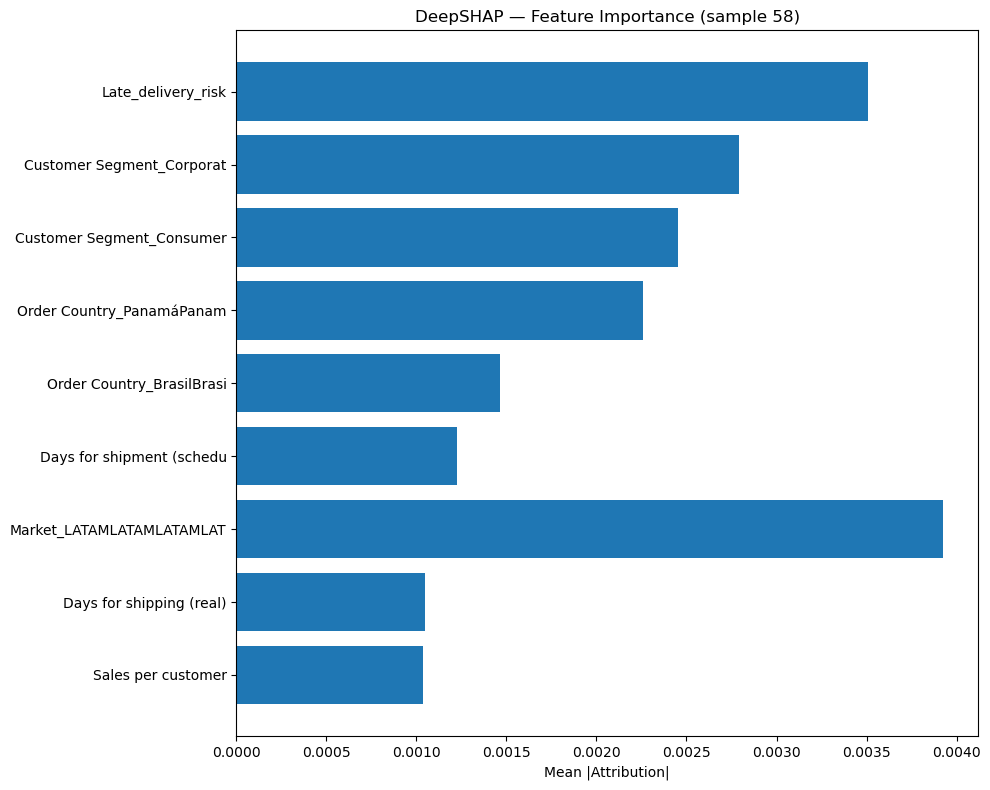

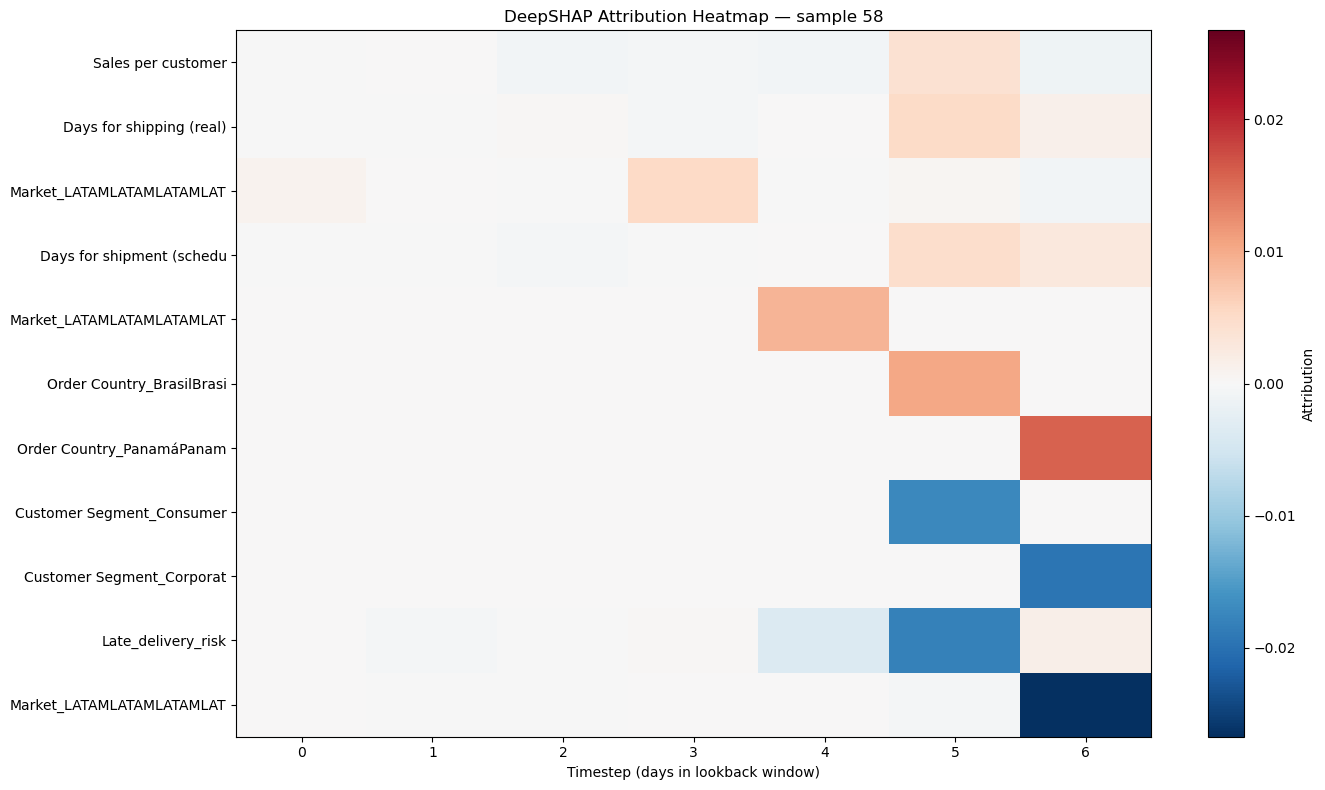

In [314]:
# Deep SHAP
from captum.attr import DeepLiftShap

dshap = DeepLiftShap(model)
baseline = X_train_tensor[:200] 

model.eval()
attributions_dshap = dshap.attribute(X_sample, baseline)
attributions_dshap = attributions_dshap.squeeze(0).detach().numpy() 

# Feature importance
feature_importance_dshap = np.abs(attributions_dshap).mean(axis=0)

# Plot top 10 features
top_k   = 11
top_id = np.argsort(feature_importance_dshap)[-top_k:]
top_names = [short_names[i] for i in top_id]
top_vals = feature_importance_dshap[top_id]

plt.figure(figsize=(10, 8))
plt.barh(top_names, top_vals)
plt.xlabel("Mean |Attribution|")
plt.title(f"DeepSHAP — Feature Importance (sample {sample_id})")
plt.tight_layout()
plt.savefig('dshap_feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

# Heatmap
attr_matrix = attributions_dshap[:, top_id]

plt.figure(figsize=(14, 8))
plt.imshow(attr_matrix.T, aspect='auto', cmap='RdBu_r',
           vmin=-np.abs(attr_matrix).max(), vmax=np.abs(attr_matrix).max())
plt.colorbar(label="Attribution")
plt.yticks(range(top_k), top_names)
plt.xticks(range(attr_matrix.shape[0]))
plt.xlabel("Timestep (days in lookback window)")
plt.title(f"DeepSHAP Attribution Heatmap — sample {sample_id}")
plt.tight_layout()
plt.savefig('dshap_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()